## PAPER WALKTHROUGH 

In [1]:
import numpy as np
import matplotlib.pyplot as plt


import sys
import os

sys.path.append(os.path.abspath("../src"))

In [2]:
from batchnorm import BatchNorm
from neural_network import NeuralNetwork

In [3]:
x = np.random.normal(loc=100,scale=25,size=(32,10))

print(f"This is the shape of our input data: {x.shape}")



This is the shape of our input data: (32, 10)


In [4]:
batch = BatchNorm()
scaled_x = batch.forward(x)

print(f"this is the shape of scaled_x: {scaled_x.shape}")

print(f"This is the scaled_x: {scaled_x}")

this is the shape of scaled_x: (32, 10)
This is the scaled_x: [[-2.20706118e+00 -4.75204022e-01 -9.99526316e-01  4.50421199e-01
   8.65589323e-01 -1.76332999e+00  2.81559175e-01  1.05767826e+00
   6.39207302e-01 -5.31881755e-01]
 [ 4.08066738e-01  1.02960156e-01  7.95715472e-01  7.47107161e-01
   9.74783237e-01 -1.44510026e-03 -9.85621752e-01 -5.51116744e-01
  -2.12287328e-01  1.44087420e+00]
 [ 3.08741281e-01  7.20747602e-01 -1.56837806e-01  8.47693610e-01
   1.43923422e-01 -1.09928471e+00 -1.02296770e+00 -1.39726507e+00
   2.22710201e-01 -1.53684643e-01]
 [-9.34675641e-01  2.97997322e-01  1.24926453e+00  2.91746032e-01
   2.11570097e-01  3.20708478e-01  2.83016084e-01 -1.65293989e+00
   1.43154760e-01  1.83924499e+00]
 [-1.10495607e+00 -1.62475803e+00 -9.25743787e-02 -1.60323382e+00
   1.97132672e+00 -1.51024550e-01 -4.15819206e-02 -3.26798734e-01
  -7.55251110e-01  1.00631154e+00]
 [-1.06518057e+00  4.11399324e-02 -9.31021654e-01 -1.33985921e+00
  -2.69135047e-02 -5.01644911e-01 -4.

In [5]:
print(f"The mean is this: {np.mean(scaled_x)}")
print(f"The variance is this: {np.var(scaled_x)}")


The mean is this: -1.1657341758564144e-16
The variance is this: 0.999999981926998


### Neural Network Forward Pass

In [6]:
network = NeuralNetwork(10,5)

batch = BatchNorm()

network.forward(x,batch)

this is the shape of Z1: (32, 5)
this is the shape of Z2: (32, 5)


array([[1.49195006, 1.26696392, 0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.25426383, 0.17111748, 0.00280765],
       [0.        , 0.41865424, 0.0335254 , 1.61858503, 0.        ],
       [0.        , 0.        , 0.62636984, 0.        , 0.18240579],
       [0.99831527, 0.1902757 , 0.        , 0.        , 1.21774217],
       [0.73036804, 0.51910661, 0.        , 0.        , 0.        ],
       [0.52309946, 0.02857627, 0.55125206, 0.        , 0.18058877],
       [1.34920253, 0.        , 0.96889574, 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.28662969, 1.22610026],
       [0.        , 1.88670365, 0.        , 0.        , 1.5896133 ],
       [0.24968836, 0.        , 1.1118751 , 0.23792707, 0.        ],
       [0.        , 0.97223646, 0.        , 2.04571537, 0.        ],
       [0.        , 0.        , 0.94069837, 0.95363355, 0.        ],
       [0.        , 0.        , 1.24533223, 0.        , 1.18454495],
       [0.20561298, 0.        , 0.

### Visualization

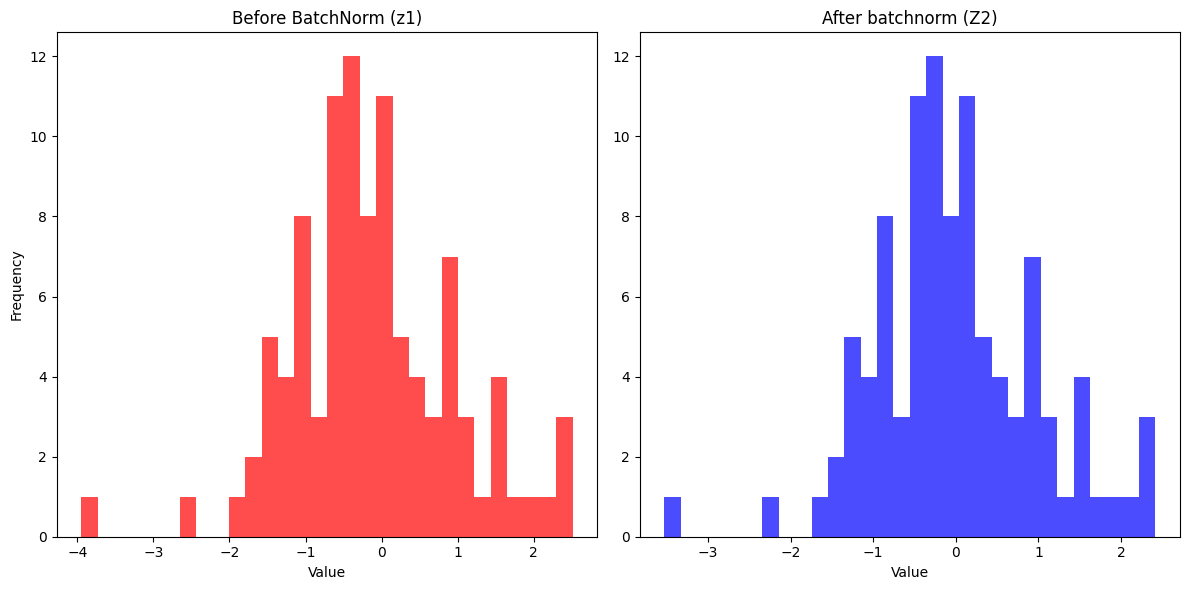

In [7]:
x_messy = np.random.normal(loc=0,scale=1,size=(100,1))

bn = BatchNorm()


x_normalized = bn.forward(x_messy)

plt.figure(figsize=(12,6))


plt.subplot(1,2,1)
plt.hist(x_messy,bins=30,color="red",alpha=0.7)

plt.title("Before BatchNorm (z1)")

plt.xlabel("Value")
plt.ylabel("Frequency")



plt.subplot(1,2,2)
plt.hist(x_normalized,bins=30,color="blue",alpha=0.7)
plt.title("After batchnorm (Z2)")
plt.xlabel("Value")


plt.tight_layout()
plt.show()

## BACKPROPAGATION

In [8]:
bn = BatchNorm()

y = bn.forward(x)

print(f"Beta shape after fresh start: {bn.beta.shape}")

dout = np.random.randn(*y.shape)

Beta shape after fresh start: (1, 10)


### Numerical Error

In [9]:





epsilon = 1e-5
grad_num_x = np.zeros_like(x)

grad_num_beta = np.zeros_like(bn.beta)
grad_num_gamma = np.zeros_like(bn.gamma)


print(f"Shape of x: {x.shape}")
print(f"shape of beta is: {bn.beta.shape}")
print(f"shape of gamma is: {bn.gamma.shape}")


for i in range(x.shape[0]):
    for j in range(x.shape[1]):
        
        original_val = x[i,j]
        
        #print(original_val)
        #print(f"what is in i: {x[i]}\n what is in j : {x[j]}")
        
        x[i,j] = original_val + epsilon
        
        y_pos = bn.forward(x)
        
        l_pos = np.sum(y_pos*dout)
        
        x[i,j] = original_val - epsilon
        
        y_neg = bn.forward(x)
        l_neg = np.sum(y_neg * dout)
        
        x[i,j] = original_val
        
        grad_num_x[i,j] =(l_pos - l_neg)/ (2 * epsilon)
        
        
        
for j in range(bn.beta.shape[1]):
          #########BETA###############
        original_beta = bn.beta[0,j]
        
        
        bn.beta[0,j] = original_beta + epsilon
        y_b_pos = bn.forward(x)
        
        l_b_pos = np.sum(y_b_pos * dout)
        
        bn.beta[0,j] = original_beta - epsilon
        y_b_neg = bn.forward(x)
        
        l_b_neg = np.sum(y_b_neg * dout)
        
        bn.beta[0, j] = original_beta
    
        # Calculate gradient
        grad_num_beta[0, j] = (l_b_pos - l_b_neg) / (2 * epsilon)
        
        
        
for j in range(bn.gamma.shape[1]):
          #########BETA###############
        original_gamma = bn.gamma[0,j]
        
        
        bn.gamma[0,j] = original_gamma + epsilon
        y_b_pos = bn.forward(x)
        
        l_b_pos = np.sum(y_b_pos * dout)
        
        bn.gamma[0,j] = original_gamma - epsilon
        y_b_neg = bn.forward(x)
        
        l_b_neg = np.sum(y_b_neg * dout)
        
        bn.gamma[0, j] = original_gamma
    
        # Calculate gradient
        grad_num_gamma[0, j] = (l_b_pos - l_b_neg) / (2 * epsilon)
        
        
        
        
print(f"Shape of grad_num_x: {grad_num_x.shape}")
print(f"Shape of grad_num_beta: {grad_num_beta.shape}")

print(f"Shape of grad_num_gamma: {grad_num_gamma.shape}")
        
        
    

Shape of x: (32, 10)
shape of beta is: (1, 10)
shape of gamma is: (1, 10)
Shape of grad_num_x: (32, 10)
Shape of grad_num_beta: (1, 10)
Shape of grad_num_gamma: (1, 10)


## Analytical Error

In [11]:




dx_analytical,d_beta_analytical,d_gamma_analytical,dx = bn.backward(dout)

print(f"Analytical dx shape: {dx_analytical.shape}")
print(f"Beta dx shape: {d_beta_analytical.shape}")
print("First few values of analytical dx:")
print(dx_analytical[0,:5])

The shape of d_normalized: (32, 10)
The shape of batch_mean : (1, 10)
The shape of d_var : (10,)
The shape of d_mean :(10,)
Analytical dx shape: (32, 10)
Beta dx shape: (1, 10)
First few values of analytical dx:
[-0.03405934 -0.00032839  0.01837876  0.01558185  0.06414829]


In [12]:
# Assuming your loop for grad_num_x is finished
rel_error = np.max(np.abs(dx_analytical - grad_num_x) / np.maximum(1e-8, np.abs(dx_analytical) + np.abs(grad_num_x)))

print(f"Maximum Relative Error: {rel_error}")

Maximum Relative Error: 1.1516857229623442e-06


In [13]:
print("Analytical d_beta:", d_beta_analytical[0, :5])
print("Numerical d_beta:", grad_num_beta[0, :5])

Analytical d_beta: [-1.13437642 -1.5241725  -4.78480026 -3.52620064  1.22954742]
Numerical d_beta: [-1.13437642 -1.5241725  -4.78480026 -3.52620064  1.22954742]


In [14]:
# Assuming your loop for grad_num_x is finished
rel_error = np.max(np.abs(d_beta_analytical - grad_num_beta) / np.maximum(1e-8, np.abs(d_beta_analytical) + np.abs(grad_num_beta)))

print(f"Maximum Relative Error: {rel_error}")

Maximum Relative Error: 9.796937086129929e-11


In [15]:
# Assuming your loop for grad_num_x is finished
rel_error = np.max(np.abs(d_gamma_analytical - grad_num_gamma) / np.maximum(1e-8, np.abs(d_gamma_analytical) + np.abs(grad_num_gamma)))

print(f"Maximum Relative Error: {rel_error}")

Maximum Relative Error: 1.0812529862125991e-10


## Validate Behaviour Difference

In [ ]:
validate_x = (x[-5:-1])
print(validate_x.shape)validate_x = (x[-5:-1])
print(validate_x.shape)

(4, 10)


In [23]:
bn_validate = BatchNorm()

In [25]:
output_train_x = bn_validate.forward(validate_x)
print(f"output in train mode: {output_train_x}")

output in train mode: [[ 6.77302971e-01 -1.36078075e-02 -8.21237255e-01  1.67164725e+00
  -1.39121069e+00 -4.06648306e-01  3.21600110e-01 -1.34849146e+00
  -1.57913361e+00  1.43533928e+00]
 [-1.54176087e+00 -1.22413684e+00  1.02944571e+00 -8.42881133e-01
   3.73905413e-01 -1.14702201e+00 -4.11138641e-01 -2.53078424e-01
   5.80235082e-01  1.45955821e-04]
 [ 1.06095394e+00 -3.12604402e-01  9.55172763e-01 -1.38956074e-01
  -3.30177633e-01  1.58678288e+00 -1.31969579e+00  1.54639200e-01
   1.07857142e+00 -1.39209124e+00]
 [-1.96496036e-01  1.55034905e+00 -1.16338122e+00 -6.89810043e-01
   1.34748291e+00 -3.31125601e-02  1.40923432e+00  1.44693069e+00
  -7.96728914e-02 -4.33939962e-02]]


In [26]:
output_eval_x = bn_validate.forward(validate_x,"eval")
print(f"output in eval mode: {output_eval_x}")

output in eval mode: [[22.71033318 12.60598297  4.16617146 24.22723781 10.16174237 39.41954296
   8.80891802 23.64138782 20.89763962 17.96390808]
 [15.80875175  8.83634581 10.00214708 16.43646836 15.69945293 37.36431695
   6.49904698 26.96501814 27.55629141 13.46758353]
 [23.90353832 11.67489529  9.76793348 18.6174411  13.49052849 44.95316956
   3.63492953 28.20208818 29.09296653  9.10583645]
 [19.99270294 17.4762089   3.08724877 16.9107289  18.75386413 40.45645226
  12.23755443 32.12307415 25.52139231 13.33117699]]


In [28]:
# 1. The "Black Hole" image (All zeros)
crazy_zeros = np.zeros((1, 10)) 

# 2. The "Supernova" image (Massive values)
crazy_huge = np.ones((1, 10)) * 1e6 

# 3. A "Mixed" batch
# We take the first image from your validate_x and pair it with the Supernova
mixed_batch = np.vstack([validate_x[0:1], crazy_huge])

print(mixed_batch)

[[1.31138724e+02 7.63946498e+01 6.23549571e+01 1.24878219e+02
  8.90716745e+01 8.69997202e+01 1.16101169e+02 8.99678987e+01
  1.01692200e+02 1.35767958e+02]
 [1.00000000e+06 1.00000000e+06 1.00000000e+06 1.00000000e+06
  1.00000000e+06 1.00000000e+06 1.00000000e+06 1.00000000e+06
  1.00000000e+06 1.00000000e+06]]


In [37]:
output_eval_mixed = bn_validate.forward(mixed_batch, "eval")
print(f"output in eval mode: {output_eval_mixed}")

output in eval mode: [[-0.43544709 -0.43563443 -0.43569352 -0.43546301 -0.4356042  -0.4355997
  -0.43549698 -0.43559406 -0.43555746 -0.43542404]
 [ 4.15286759  4.15268025  4.15262115  4.15285166  4.15271047  4.15271498
   4.15281769  4.15272062  4.15275722  4.15289063]]


In [32]:
output_train_mixed = bn_validate.forward(mixed_batch, "train")
print(f"output in train mode: {output_train_mixed}")

output in train mode: [[-1. -1. -1. -1. -1. -1. -1. -1. -1. -1.]
 [ 1.  1.  1.  1.  1.  1.  1.  1.  1.  1.]]
